## Data Science for Social Impact 
# Homework Thursday: Statistics

Please complete this notebook by filling in the cells provided. The solved homework should be uploaded to Gradescope on Canvas.

#### Deadline:

This assignment is due on **Thursday at 11:30pm**.

Directly sharing answers is not okay, but discussing problems with eachother is encouraged!


In [2]:
# Don't change this cell; just run it. 

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression

from matplotlib import pyplot as plt
plt.style.use('fivethirtyeight')

## Testing Diabetes

Load and familiarize yourself with the data file `diabetes_full.csv`. This data comes in part from Kaggle (I have made a few additions) and has the following description:

The Diabetes prediction dataset is a collection of medical and demographic data from patients, along with their diabetes status (positive or negative). The data includes features such as age, gender, body mass index (BMI), hypertension, heart disease, smoking history, HbA1c level, and blood glucose level. This dataset can be used to build machine learning models to predict diabetes in patients based on their medical history and demographic information. This can be useful for healthcare professionals in identifying patients who may be at risk of developing diabetes and in developing personalized treatment plans. Additionally, the dataset can be used by researchers to explore the relationships between various medical and demographic factors and the likelihood of developing diabetes.

In [5]:
# Use this cell to read in your data and inspect the first and last few lines
db = pd.read_csv("diabetes_full.csv")
db

,Unnamed: 0,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,PID,Year
0,0,Female,80.0,0,1,never,25.19,6.6,140,0,1000,2021
1,1,Female,54.0,0,0,No Info,27.32,6.6,80,0,2000,2021
2,2,Male,28.0,0,0,never,27.32,5.7,158,0,3000,2021
3,3,Female,36.0,0,0,current,23.45,5.0,155,0,4000,2021
4,4,Male,76.0,1,1,current,20.14,4.8,155,0,5000,2021
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,99995,Female,81.0,0,0,No Info,27.32,6.2,90,0,99996000,2022
199996,99996,Female,3.0,0,0,No Info,17.37,6.5,100,0,99997000,2022
199997,99997,Male,67.0,0,0,former,27.83,5.7,155,0,99998000,2022
199998,99998,Female,25.0,0,0,never,35.42,4.0,100,0,99999000,2022


**Question 1.** According to the CDC, the average BMI in the US is 26.5. I am curious whether the average BMI in this data is similar.

**a)** State the null and alternative hypotheses you would use to investigate this.

Replace this text with your answer

H0: Average BMI == 26.5

HA: Average BMI != 26.5

**b)** Does our data meet the assumptions necessary to do a t-test? Why or why not?

In [ ]:
# Your code here

Replace this text with your answer

Data is independent and continuous and large enough we can assume normality so yes. (May or may not be a random sample, but we are testing if its a representative sample so this is ok)

**c)** Assume your answer to part b is yes (If you answered no you are not necessarily wrong, just assume this for now.). Which of the 3 types of t-tests would you use to answer this question?

Replace this text with your answer

one sample t-test

**d)** Run the test and report the result. What is your conclusion? Is the average BMI similar?

In [6]:
# Your code here
print("Average in our data", np.mean(db.bmi))

t_stat, p_value = stats.ttest_1samp(db.bmi, 26.5, nan_policy='omit')
print("T-statistic value: ", t_stat)  
print("P-Value: ", p_value)

Average in our data 27.320767099999994
T-statistic value:  55.30678047920735
P-Value:  0.0


Reject the null that the average is similar. Looking at the average bmi in our data, it is significantly larger.

**Question 2.** Using the same data, I now want to know if the average bmi is different for men than women.

**a)** State the null and alternative hypotheses you would use to investigate this.

H0: Average BMI for men = Average BMI for women

HA: Average BMI for men != Average BMI for women

**b)** Does our data meet the assumptions necessary to do a t-test? Why or why not?

In [7]:
# Your code here

print(db.loc[db.gender == "Male"].bmi.std())
print(db.loc[db.gender == "Female"].bmi.std())

6.223999985879538
6.9112161436004556


Replace this text with your answer

Data is independent,continuous, large enough we can assume normality, and has similar variance so yes.



**c)** Assume your answer to part b is yes (If you answered no you are not necessarily wrong, just assume this for now.). Which of the 3 types of t-tests would you use to answer this question?

Replace this text with your answer

Independent samples t-test

**d)** Run the test and report the result. What is your conclusion? Is the average BMI different?

In [8]:
# Your code here

print(db.loc[db.gender == "Male"].bmi.mean())
print(db.loc[db.gender == "Female"].bmi.mean())

t_stat, p_value = stats.ttest_ind(db.loc[db.gender == "Male"].bmi, db.loc[db.gender == "Female"].bmi)
print("T-statistic value: ", t_stat)  
print("P-Value: ", p_value)

27.139107651460293
27.4492869586009
T-statistic value:  -10.297888531851164
P-Value:  7.3063565644094075e-25


Replace this text with your answer

Average BMI is significantly lower for males.

**Question 3.** In this dataset, we have 2 years of data. Is the rate of diabetes in this population significantly higher in 2022 than in 2021?

**a)** State the null and alternative hypotheses you would use to investigate this.

Replace this text with your answer

H0: Incidence rate in 2022 = Incidence rate in 2021

HA: Incidence rate in 2022 > Incidence rate in 2021

**b)** Does our data meet the assumptions necessary to do a t-test? Why or why not?

Replace this text with your answer

No, it is binary and not continuous

**c)** Assume your answer to part b is yes (If you answered no you are not necessarily wrong, just assume this for now.). Which of the 3 types of t-tests would you use to answer this question?

Replace this text with your answer

Paired, one-sided, t-test



**d)** Run the test and report the result. What is your conclusion? Is the incidence rate higher?

In [ ]:
# Your code here
print(db.loc[db.Year == 2022].diabetes.mean())
print(db.loc[db.Year == 2021].diabetes.mean())

t_stat, p_value = stats.ttest_rel(db.loc[db.Year == 2022].diabetes, db.loc[db.Year == 2021].diabetes, alternative='greater')
print("T-statistic value: ", t_stat)  
print("P-Value: ", p_value)

0.08419
0.085
T-statistic value:  -8.40223107283497
P-Value:  1.0


Replace this text with your answer

We cannot reject the null hypothesis that the incident rates are the same.

**Question 4.** I am curious which of these variables is most closely related with developing diabetes.

**a)** Can I test this using linear regression? Why or why not?

Replace this text with your answer

No, diabetes is not continuous

**b)** What is a question you could answer using linear regression on this dataset? (Do not look ahead, use one of your own)

Replace this text with your answer

Students can choose any 2 continuous variables

**c)** Look at only data from 2021. Find the least squares regression line for age and bmi. Is there a linear relationship between age and bmi? If so, characterise the trend.

In [ ]:
# Your code here

db21 = db.loc[db.Year == 2021]

model = LinearRegression()
model.fit(db21['age'].to_numpy().reshape((-1, 1)), db21['bmi'].to_numpy())
r_sq = model.score(db21['age'].to_numpy().reshape((-1, 1)), db21['bmi'].to_numpy())

print("coefficient of determination", r_sq)
print("intercept:", model.intercept_)
print("slope", model.coef_)

coefficient of determination 0.1138359097882713
intercept: 23.155362017677284
slope [0.09944658]


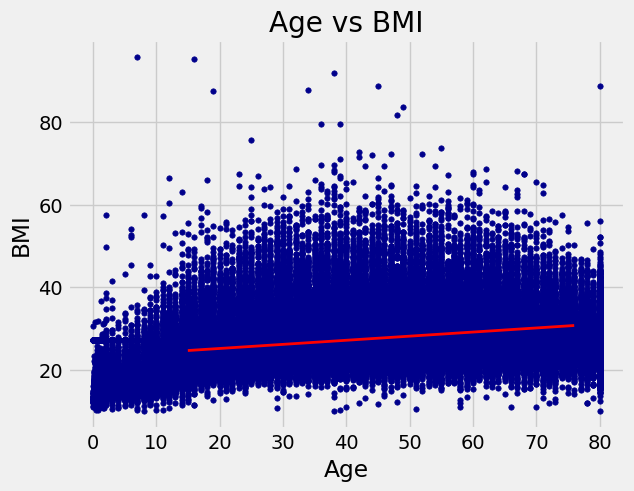

In [ ]:
plt.scatter(db21['age'],db21['bmi'],c="darkblue",s=15)
plt.xlabel("Age")
plt.ylabel("BMI")
xlims = np.array([0, 80])
plt.plot(xlims, model.coef_ * xlims + model.intercept_, lw=2,color='red')
plt.title("Age vs BMI")
plt.show()

Replace this text with your answer

**e)** A patient comes in who is a 65 year old male with a blood glucose level of 158. What would you predict his bmi to be using your model from part d? What do you conclude about predicting bmi from age?

In [ ]:
# Your code here

y_pred = model.coef_[0]*(65) + model.intercept_
y_pred

29.61938964435338

Replace this text with your answer

A lot of variance

Not really linear

More than just age determines bmi